## 1. Setup

### 1.0 Google Drive Sync

In [14]:
# Adicionar o conteúdo do drive no caminho do sistema

#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

In [15]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!dir

[WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/projetos-if702/projeto-churn/'
c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn
 Volume in drive C has no label.
 Volume Serial Number is 92E5-FB3A

 Directory of c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn

06/06/2026  11:14 AM    <DIR>          .
06/06/2026  11:14 AM    <DIR>          ..
06/05/2026  07:56 PM             4,428 0_preprocessamento.ipynb
06/05/2026  11:13 PM           264,459 1_MLP.ipynb
06/04/2026  04:14 PM           395,387 2_XGBoost.ipynb
06/04/2026  04:14 PM             9,732 churn_preprocessing.py
06/05/2026  07:57 PM    <DIR>          datasets
06/06/2026  12:46 PM           233,831 KAN.ipynb
06/06/2026  12:52 PM            27,955 ml_utils.py
06/05/2026  09:53 PM    <DIR>          model
06/06/2026  12:30 AM    <DIR>          models
06/06/2026  12:30 AM    <DIR>          results
06/05/2026  11:40 PM    <DIR>          searches
06/04/2026  02:42 PM      

In [16]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [17]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.1 Importar Libs

In [18]:
# Importação das bibliotecas necessárias
import pandas as pd
import optuna 
import optuna.visualization as optuna_vis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform, randint
from joblib import dump, load
import warnings


warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
import torch
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load

from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn, _preprocess_model_params,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
)
from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL
try:
    from tabkan import ChebyshevKAN
except:
    print("❌ TabKAN não encontrado. Instale com: pip install tabkan")

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 2.3.1
NumPy: 2.3.2
Scikit-learn: 1.7.2
Device: CUDA


### 1.2 Configuração do Modelo

In [19]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "TabKAN"
MODEL_CLASS = ChebyshevKAN

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
tabkan_params = [
    "layers",
    "orders",
    "lr",
    "steps",
    "batch_size",
]
for param in tabkan_params:
    print(f"  - {param}")

Modelo configurado: TabKAN
tabkan.chebyshev.model
Hiperparâmetros disponíveis na classe do modelo:
  - layers
  - orders
  - lr
  - steps
  - batch_size


## 2. Carregamento e Preparação dos Dados

In [20]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

X_train_scaled = X_train
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [21]:
train_data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Sampling para Busca de Hiperparâmetros

### 3.0 Sampling para busca

In [22]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [23]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [24]:
# Optuna
n_trials = 100
scoring_metric = 'ks'
loss_fn = get_loss_fn('bce_with_logits')

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

In [25]:
import inspect
print(inspect.signature(ChebyshevKAN.__init__))

(self, layers, orders)


### 3.2 Definição do espaço de hiperparâmetros

In [26]:
tabkan_architectures = [
    # 1 camada oculta
    {"layers_hidden": [32],        "orders": [2]},
    {"layers_hidden": [32],        "orders": [4]},
    {"layers_hidden": [64],        "orders": [2]},
    {"layers_hidden": [64],        "orders": [4]},
    # 2 camadas ocultas
    {"layers_hidden": [64, 32],    "orders": [2, 2]},
    {"layers_hidden": [64, 32],    "orders": [4, 4]},
    {"layers_hidden": [128, 64],   "orders": [2, 2]},
    {"layers_hidden": [128, 64],   "orders": [4, 4]},
    # 3 camadas ocultas
    {"layers_hidden": [128, 64, 32],     "orders": [2, 2, 2]},
    {"layers_hidden": [128, 64, 32],     "orders": [4, 4, 4]},
    # 4 camadas ocultas
    {"layers_hidden": [128, 64, 32, 16], "orders": [2, 2, 2, 2]},
    {"layers_hidden": [128, 64, 32, 16], "orders": [4, 4, 4, 4]},
]

param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "architecture_idx": {"type": "int", "values": [0, len(tabkan_architectures) - 1]},
        "lr": {"type": "float", "values": [1e-4, 1e-1, None, True]},
        "batch_size": {"type": "categorical", "values": [32, 64, 128, 256]},
    },
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- architecture_idx: type=int, args=[0, 11], kwargs={}
- lr: type=float, args=[0.0001, 0.1], kwargs={'log': True}
- batch_size: type=categorical, values=[32, 64, 128, 256]


### 3.3 Executar Busca de Hiperparâmetros

In [27]:
print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"

=== BUSCA DE HIPERPARÂMETROS - TabKAN ===
Iniciando busca de hiperparâmetros para TabKAN...
Trials: 100
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['architecture_idx', 'lr', 'batch_size']


In [28]:
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
    extra_context={"tabkan_architectures": tabkan_architectures},
)

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-06-06 12:55:46,608] A new study created in memory with name: no-name-81d06729-3a72-4c0d-9a93-3fa590e7b67f
[I 2026-06-06 12:55:47,732] Trial 0 finished with value: 0.43155452436194897 and parameters: {'architecture_idx': 8, 'lr': 0.009265143929587001, 'batch_size': 256}. Best is trial 0 with value: 0.43155452436194897.
[I 2026-06-06 12:55:47,951] Trial 1 finished with value: 0.48878576952822894 and parameters: {'architecture_idx': 0, 'lr': 0.004125669757777167, 'batch_size': 64}. Best is trial 1 with value: 0.48878576952822894.
[I 2026-06-06 12:55:48,435] Trial 2 finished with value: 0.4756380510440836 and parameters: {'architecture_idx': 5, 'lr': 0.029226990236736347, 'batch_size': 64}. Best is trial 1 with value: 0.48878576952822894.
[I 2026-06-06 12:55:48,581] Trial 3 finished with value: 0.44934261407579273 and parameters: {'architecture_idx': 4, 'lr': 0.002185800429291121, 'batch_size': 256}. Best is trial 1 with value: 0.48878576952822894.
[I 2026-06-06 12:55:48,798] Trial


--- RESULTADOS TabKAN ---
Melhores hiperparâmetros encontrados:
  architecture_idx: 2
  lr: 0.006502712566182901
  batch_size: 32

Melhor score (ks): 0.517401


### 3.4 Visualizar histórico da busca

In [29]:
optuna_vis.plot_param_importances(study)

In [30]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)

In [31]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [32]:
print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - TabKAN ===

Top configurações (de 100 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_architecture_idx  params_batch_size  params_lr    state
     46 0.517401 2026-06-06 12:56:03.800486 2026-06-06 12:56:04.197103 0 days 00:00:00.396617                        2                 32   0.006503 COMPLETE
     99 0.515855 2026-06-06 12:56:25.645304 2026-06-06 12:56:26.144158 0 days 00:00:00.498854                        3                 32   0.004484 COMPLETE
     92 0.515855 2026-06-06 12:56:22.800790 2026-06-06 12:56:23.295400 0 days 00:00:00.494610                        3                 32   0.002260 COMPLETE
     79 0.512761 2026-06-06 12:56:16.711711 2026-06-06 12:56:17.214983 0 days 00:00:00.503272                        1                 32   0.003196 COMPLETE
     23 0.511214 2026-06-06 12:55:56.313716 2026-06-06 12:55:56.484479 0 days 00:00:00.170763                   

## 4. Salvar Resultados de Busca

In [33]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

In [34]:
trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches\tabkan_optuna_trials.csv
searches\tabkan_optuna_best.json


In [35]:
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [36]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

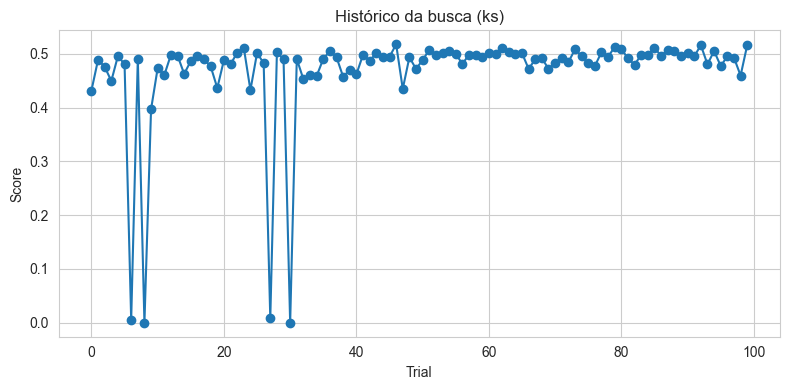

In [37]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [38]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

✅ Usando parâmetros carregados: {'architecture_idx': 2, 'lr': 0.006502712566182901, 'batch_size': 32}
✅ Melhor score carregado: 0.517401


## 7. Treinar Modelo Final e Salvar

In [39]:
best_params_with_arch = best_params.copy()
best_params_with_arch["tabkan_architectures"] = tabkan_architectures

best_params_model = _preprocess_model_params(
    ChebyshevKAN, best_params.copy(), {},
    X_train_scaled,
    extra_context={"tabkan_architectures": tabkan_architectures},
)
lr = best_params_model.pop("lr", best_params.get("lr", 1e-3))
best_params_model.pop("batch_size", None)

best_model = ChebyshevKAN(**best_params_model)
best_model.to(device)

optimizer = torch.optim.Adam(best_model.parameters(), lr=lr)

train_result = train_model(
    model=best_model,
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
)
best_model = train_result["model"]

In [40]:
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.pt')
torch.save(best_model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: models\tabkan_model.pt


## 8. Avaliação Final e Salvamento dos Resultados

In [41]:
# Carregar modelo (Opcional)
n_features = X_train_scaled.shape[1]
arch_idx = best_params["architecture_idx"]
arch = tabkan_architectures[int(arch_idx)]

loaded_model = ChebyshevKAN(
    layers=[n_features] + arch["layers_hidden"] + [1],
    orders=arch["orders"],
)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.to(device)

ChebyshevKAN(
  (layers): ModuleList(
    (0): ChebyKANLayer()
    (1): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [42]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
 )
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
 )

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - TabKAN ===

Avaliando: TabKAN


### 8.1 Classification Report

In [43]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1294
           1       0.51      0.78      0.61       468

    accuracy                           0.74      1762
   macro avg       0.70      0.75      0.71      1762
weighted avg       0.80      0.74      0.75      1762



KS Statistic: 0.5192


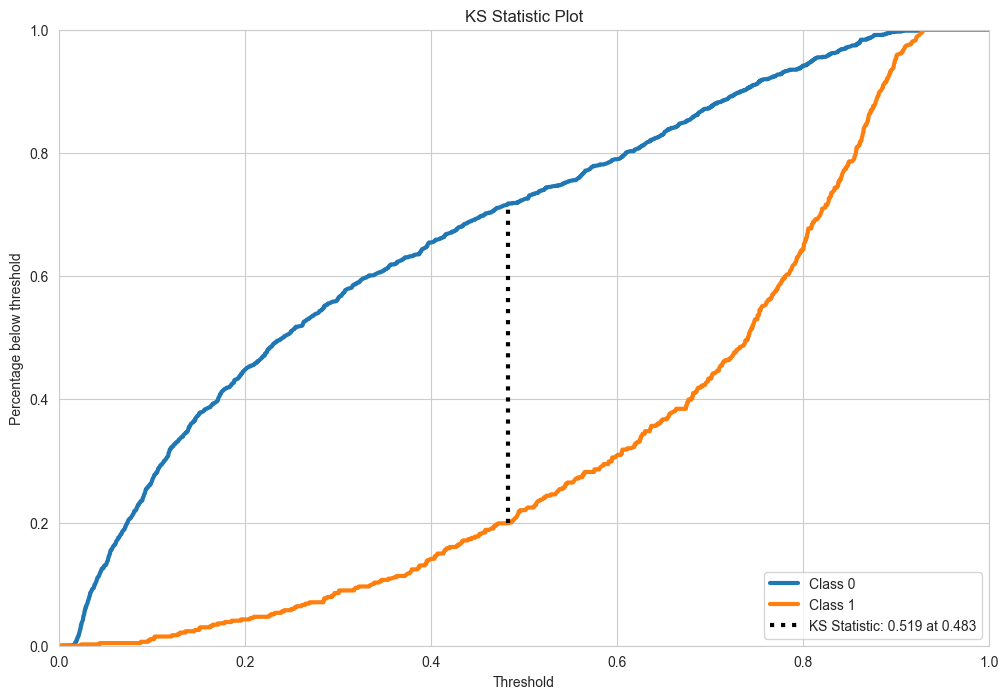

In [44]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)

### 8.2 Visualize Confusion Matrix

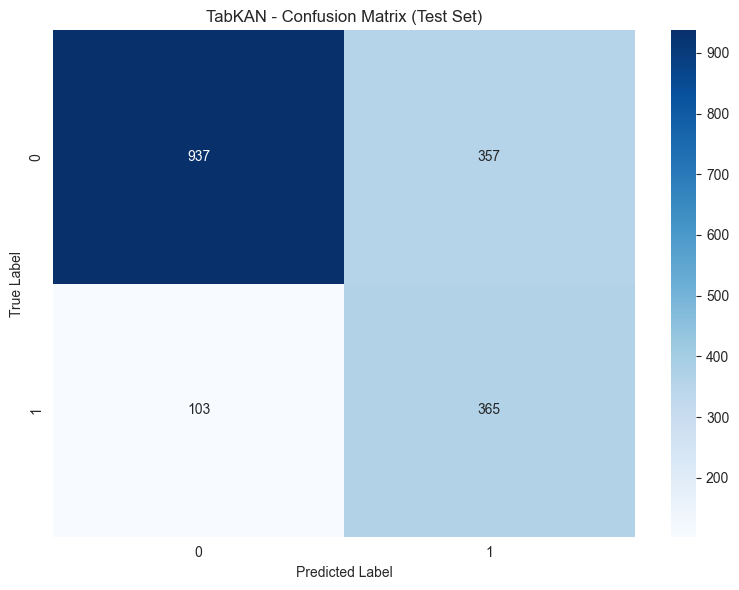

In [45]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [46]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL TabKAN ---
Score da busca: 0.517401
KS Statistic Teste: 0.5192
AUC-ROC Teste: 0.8361
F1-Score Teste: 0.6134
Acurácia Teste: 0.7389
Precisão Teste: 0.5055
Recall Teste: 0.7799
Resultados salvos em: results/
Arquivo final: results\tabkan_final_results.json
